# 05 — Análisis de Sesgos

**Objetivo:** Evaluar los sesgos presentes en los datasets de ofertas de empleo y en la encuesta de Stack Overflow, y estimar su posible impacto en las decisiones de DataTalent Solutions.

Este notebook responde directamente a las preguntas de negocio 2 y 5:

- ¿Existen sesgos en la distribución salarial según género, ciudad o tipo de contrato?
- ¿Qué decisiones podrían tomarse a partir de datos incompletos o sesgados?

El análisis se centrará en:

- Representatividad geográfica de las ofertas.
- Completitud y distribución del dato salarial.
- Sesgos demográficos (con datos de Stack Overflow).
- Posibles distorsiones en las conclusiones si se ignora la calidad de los datos.

In [34]:
# ============================================================
# IMPORTS, CONFIGURACIÓN Y RUTAS
# ============================================================
import os, re, ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

# Rutas del proyecto (compatibles con ejecución desde notebooks/)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_RAW   = PROJECT_ROOT / "data" / "raw"
DATA_CLEAN = PROJECT_ROOT / "data" / "clean"

print("Raíz del proyecto:", PROJECT_ROOT)
print("Carpeta raw:", DATA_RAW)
print("Carpeta clean:", DATA_CLEAN)

Raíz del proyecto: /mnt/hdd/David/2026/Somos_F5/Bootcam_Desarrollo_IA/Proyectos/Modulo2/1_Proyecto/proyecto-eda-roles-datos
Carpeta raw: /mnt/hdd/David/2026/Somos_F5/Bootcam_Desarrollo_IA/Proyectos/Modulo2/1_Proyecto/proyecto-eda-roles-datos/data/raw
Carpeta clean: /mnt/hdd/David/2026/Somos_F5/Bootcam_Desarrollo_IA/Proyectos/Modulo2/1_Proyecto/proyecto-eda-roles-datos/data/clean


In [35]:
# ============================================================
# FUNCIONES DE LIMPIEZA (adaptadas de 02_cleaning.ipynb)
# ============================================================

def normalize_column_names(df):
    """Normaliza nombres de columnas a snake_case básico."""
    df = df.copy()
    normalized_columns = []
    for column in df.columns:
        column_name = str(column).strip().lower()
        # Quitar acentos
        accent_map = str.maketrans("áéíóúüñ", "aeiouun")
        column_name = column_name.translate(accent_map)
        column_name = re.sub(r"[^a-z0-9]+", "_", column_name)
        column_name = re.sub(r"_+", "_", column_name).strip("_")
        normalized_columns.append(column_name)
    df.columns = normalized_columns
    return df

def clean_text(value):
    """Limpia un valor de texto: strip, nulos, 'nan', etc."""
    if pd.isna(value):
        return np.nan
    value = str(value).strip()
    if value == "" or value.lower() in ["nan", "none", "null"]:
        return np.nan
    return value

def clean_text_columns(df):
    """Aplica clean_text a todas las columnas de texto del DataFrame."""
    df = df.copy()
    text_columns = df.select_dtypes(include=["object", "string"]).columns
    for column in text_columns:
        df[column] = df[column].apply(clean_text)
    return df

def clean_salary_to_number(valor):
    """
    Extrae un salario numérico aproximado.
    Soporta formatos como '$50,000 - $70,000', '€30K - €40K', '50000', etc.
    """
    if pd.isna(valor):
        return np.nan
    texto = str(valor).lower().strip()
    valores_invalidos = [
        "", "nan", "none", "null", "not specified", "not provided",
        "unknown", "sin especificar", "no especificado", "not disclosed",
        "competitive", "competitive salary"
    ]
    if texto in valores_invalidos:
        return np.nan
    # Normalizar separadores y símbolos
    texto = texto.replace(",", "").replace("€", "").replace("$", "").replace("£", "")
    texto = texto.replace("usd", "").replace("eur", "").replace("gbp", "")
    coincidencias = re.findall(r"\d+(?:\.\d+)?\s*k?|\d+(?:\.\d+)?", texto)
    if len(coincidencias) == 0:
        return np.nan
    numeros = []
    for item in coincidencias:
        item = item.strip()
        if "k" in item:
            numeros.append(float(item.replace("k", "")) * 1000)
        else:
            numeros.append(float(item))
    return np.mean(numeros) if numeros else np.nan

# Alias de columnas de scraping (mapeo español -> estándar)
scraping_column_aliases = {
    "titulo": "job_title",
    "empresa": "company",
    "ubicacion": "location",
    "enlace": "link",
    "metadatos": "job_type",      # aproximación: contiene tipo de contrato y categoría
    "descripcion": "description",  # se conserva como columna extra
    "salary": "salary_raw"         # renombramos para limpiar después
}

# Columnas estándar del dataset unificado
job_standard_columns = [
    "job_title", "company", "location", "salary", "job_type",
    "post_date", "link", "skills", "industry", "seniority_level",
    "source_dataset"
]

print("Funciones de limpieza definidas correctamente.")

Funciones de limpieza definidas correctamente.


In [36]:
# ============================================================
# CARGA DE DATOS LIMPIOS DE OFERTAS (df_jobs + df_tecno)
# ============================================================

jobs_clean = pd.read_csv(DATA_CLEAN / "jobs_all_clean.csv")

print(f"Ofertas cargadas desde jobs_all_clean.csv: {len(jobs_clean):,}")
print(f"Fuentes incluidas: {jobs_clean['source_dataset'].unique()}")

Ofertas cargadas desde jobs_all_clean.csv: 1,542
Fuentes incluidas: <StringArray>
['df_jobs', 'df_tecno']
Length: 2, dtype: str


In [37]:
# ============================================================
# CARGA Y LIMPIEZA DE DATOS DE SCRAPING (Adzuna)
# ============================================================

scraping_file = DATA_RAW / "scraping_jobs_raw.csv"

if scraping_file.exists():
    # Cargar datos crudos de scraping
    scraped = pd.read_csv(scraping_file)
    
    # Normalizar nombres de columnas a snake_case
    scraped = normalize_column_names(scraped)
    
    # Renombrar columnas al estándar usando los alias definidos
    scraped.rename(columns={
        col: scraping_column_aliases.get(col, col)
        for col in scraped.columns
    }, inplace=True)
    
    # Asegurar columnas estándar (añadir las que falten como NaN)
    for col in job_standard_columns:
        if col not in scraped.columns:
            scraped[col] = np.nan
    
    # Limpiar la columna salary (del scraping) usando la función de limpieza
    if "salary_raw" in scraped.columns:
        scraped["salary"] = scraped["salary_raw"].apply(clean_salary_to_number)
        scraped.drop(columns=["salary_raw"], inplace=True)
    elif "salary" in scraped.columns:
        # Si ya existe salary (porque no se renombró), la limpiamos igual
        scraped["salary"] = scraped["salary"].apply(clean_salary_to_number)
    
    # Conservar la columna 'description' como extra si existe
    extra_cols = ["description"] if "description" in scraped.columns else []
    
    # Filtrar solo las columnas estándar más las extras
    cols_final = job_standard_columns + extra_cols
    scraped = scraped[[c for c in cols_final if c in scraped.columns]]
    
    # Limpiar textos
    scraped = clean_text_columns(scraped)
    
    # Marcar fuente
    scraped["source_dataset"] = "scraping"
    
    print(f"Ofertas de scraping cargadas y limpias: {len(scraped):,}")
    print(f"Columnas: {scraped.columns.tolist()}")
    print(f"Ofertas con salario no nulo: {scraped['salary'].notna().sum()}")
else:
    print("No se encontró scraping_jobs_raw.csv en data/raw/")
    scraped = pd.DataFrame(columns=job_standard_columns)

Ofertas de scraping cargadas y limpias: 646
Columnas: ['job_title', 'company', 'location', 'salary', 'job_type', 'post_date', 'link', 'skills', 'industry', 'seniority_level', 'source_dataset', 'description']
Ofertas con salario no nulo: 33


In [38]:
# ============================================================
# CONCATENACIÓN DE TODAS LAS FUENTES DE OFERTAS
# ============================================================

# Concatenar las dos fuentes existentes más el scraping limpio
jobs_all = pd.concat([jobs_clean, scraped], ignore_index=True)

# Eliminar duplicados exactos (mismas columnas, misma fila)
jobs_all = jobs_all.drop_duplicates()

# Reiniciar índice para tener un identificador limpio
jobs_all = jobs_all.reset_index(drop=True)

print(f"Total de ofertas unificadas: {len(jobs_all):,}")
print(f"Fuentes presentes: {jobs_all['source_dataset'].value_counts().to_dict()}")
print(f"Ofertas con salario no nulo: {jobs_all['salary'].notna().sum()}")

Total de ofertas unificadas: 2,188
Fuentes presentes: {'df_jobs': 942, 'scraping': 646, 'df_tecno': 600}
Ofertas con salario no nulo: 1104


In [39]:
# ============================================================
# CARGA DEL DATASET DE STACK OVERFLOW (SOLO DEMOGRAFÍA)
# ============================================================

stack_columns = [
    "Country",              # País
    "Age",                  # Edad
    "EdLevel",             # Nivel educativo
    "Employment",          # Situación laboral
    "ConvertedCompYearly"  # Salario anual convertido
]

stack_raw = pd.read_csv(DATA_RAW / "stackoverflow_2025_results.csv",
                        usecols=stack_columns,
                        low_memory=False)

print(f"Stack Overflow cargado: {len(stack_raw):,} filas")
print(f"Columnas: {stack_raw.columns.tolist()}")

Stack Overflow cargado: 49,191 filas
Columnas: ['Age', 'EdLevel', 'Employment', 'Country', 'ConvertedCompYearly']


In [40]:
# ============================================================
# FILTRO DE OFERTAS EN ESPAÑA
# ============================================================

# Lista de ciudades españolas (ampliada)
CIUDADES_ESPANA = [
    "madrid", "barcelona", "valencia", "sevilla", "bilbao",
    "málaga", "malaga", "zaragoza", "alicante", "murcia",
    "palma", "granada", "córdoba", "valladolid", "gijón",
    "vigo", "a coruña", "donostia", "pamplona", "santander",
    "oviedo", "salamanca", "burgos", "albacete", "león",
    "cádiz", "jaén", "almería", "huelva", "cáceres", "badajoz",
    "toledo", "ciudad real", "cuenca", "guadalajara", "segovia",
    "ávila", "zamora", "palencia", "soria", "teruel", "huesca",
    "girona", "tarragona", "lleida", "castellón", "remoto", "remote"
]

# Crear columna is_spain
jobs_all["is_spain"] = (
    # El scraping es todo España
    (jobs_all["source_dataset"] == "scraping")
    |
    # El resto: city_clean está en la lista de ciudades españolas
    (jobs_all["city_clean"].str.lower().isin(CIUDADES_ESPANA))
    |
    # O location_clean contiene "spain" o "españa"
    (jobs_all["location_clean"].str.lower().str.contains("spain|españa", na=False))
)

# Subset español
jobs_es = jobs_all[jobs_all["is_spain"] == True].copy()

print(f"Ofertas totales:        {len(jobs_all):,}")
print(f"Ofertas en España:      {len(jobs_es):,}  ({len(jobs_es)/len(jobs_all)*100:.1f}%)")
print(f"\nDistribución por fuente en España:")
print(jobs_es["source_dataset"].value_counts())

Ofertas totales:        2,188
Ofertas en España:      1,157  (52.9%)

Distribución por fuente en España:
source_dataset
scraping    646
df_tecno    419
df_jobs      92
Name: count, dtype: int64


In [41]:
# ============================================================
# COMPLETAR city_clean PARA LAS OFERTAS DE SCRAPING
# ============================================================

def extract_city_scraping(location_text):
    """
    Extrae una ciudad o 'Remote' de la columna location del scraping.
    """
    if pd.isna(location_text):
        return "Desconocida"
    text = str(location_text).strip().lower()
    if "remote" in text or "remoto" in text:
        return "Remote"
    # Si contiene una coma, tomar la primera parte (ej: "Madrid, Spain")
    if "," in text:
        text = text.split(",")[0].strip()
    # Buscar si coincide con alguna ciudad de la lista
    for city in CIUDADES_ESPANA:
        if city in text:
            return city.capitalize()
    # Si no se reconoce, devolver el texto limpio (puede ser provincia)
    return text.title() if text else "Desconocida"

# Aplicar solo a las filas donde city_clean está vacío
mask_no_city = jobs_all["city_clean"].isna()
jobs_all.loc[mask_no_city, "city_clean"] = jobs_all.loc[mask_no_city, "location"].apply(extract_city_scraping)

# Reconstruir el subset España con la nueva city_clean
jobs_es = jobs_all[jobs_all["is_spain"] == True].copy()

print("city_clean completado. Muestra de valores:")
display(jobs_es[["source_dataset", "location", "city_clean"]].head(10))

city_clean completado. Muestra de valores:


,source_dataset,location,city_clean
8,df_jobs,Fully Remote,Remote
12,df_jobs,"Minneapolis, MN . Fully Remote",Remote
15,df_jobs,Fully Remote,Remote
18,df_jobs,Fully Remote,Remote
25,df_jobs,"Remote, US . Fully Remote",Remote
34,df_jobs,"Barcelona, Catalonia, Spain",Barcelona
41,df_jobs,United States . Fully Remote,Remote
57,df_jobs,"Oregon, United States . Fully Remote",Remote
66,df_jobs,"Remote, United States . Fully Remote",Remote
68,df_jobs,"San Francisco, CA, US . Remote, US . Fully Remote",Remote


In [42]:
# ============================================================
# CREAR COLUMNA SALARIAL NUMÉRICA UNIFICADA (salary_num)
# ============================================================

# En jobs_all, 'salary_clean' existe para df_jobs y df_tecno (numérica).
# Para scraping, 'salary' ya es numérica (limpia con clean_salary_to_number).
# Unificamos ambas en 'salary_num'.
jobs_all["salary_num"] = jobs_all["salary_clean"].combine_first(jobs_all["salary"])

# Reconstruir el subset España con la nueva columna
jobs_es = jobs_all[jobs_all["is_spain"] == True].copy()

print(f"Ofertas en España con salario numérico: {jobs_es['salary_num'].notna().sum()}")
print("Ejemplo de valores:")
display(jobs_es[["source_dataset", "salary", "salary_clean", "salary_num"]].head(10))

Ofertas en España con salario numérico: 210
Ejemplo de valores:


,source_dataset,salary,salary_clean,salary_num
8,df_jobs,"€207,331",207331.00,207331.00
12,df_jobs,"€99,464 - €165,954",132709.00,132709.00
15,df_jobs,"€134,266",134266.00,134266.00
18,df_jobs,"€185,412 - €228,338",206875.00,206875.00
25,df_jobs,"€91,335 - €109,601",100468.00,100468.00
34,df_jobs,"€28,068",28068.00,28068.00
41,df_jobs,"€155,272 - €164,406",159839.00,159839.00
57,df_jobs,"€19,420 - €98,368",58894.00,58894.00
66,df_jobs,"€134,541 - €174,088",154314.50,154314.50
68,df_jobs,"€306,623",306623.00,306623.00


## 1. Sesgo de representación geográfica

¿Dónde se concentran las ofertas? ¿Hay regiones sin apenas representación?

Total de ciudades distintas en España (incl. Remote): 18
Ofertas concentradas en las 10 primeras: 1138 (98.4%)
Ofertas en el resto: 19 (1.6%)


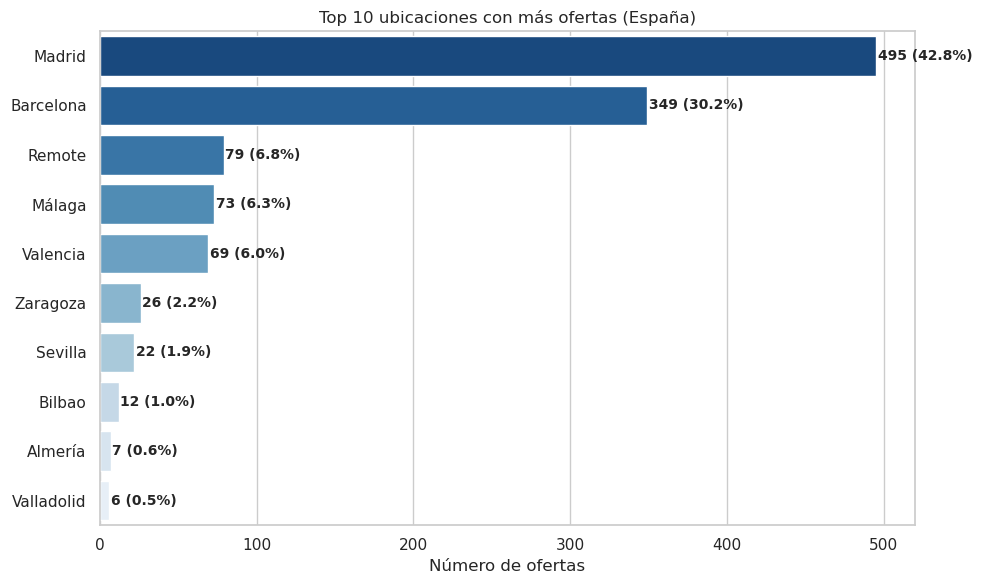


Detalle de las ubicaciones principales:
  Madrid                 495  ( 42.8%)
  Barcelona              349  ( 30.2%)
  Remote                  79  (  6.8%)
  Málaga                  73  (  6.3%)
  Valencia                69  (  6.0%)
  Zaragoza                26  (  2.2%)
  Sevilla                 22  (  1.9%)
  Bilbao                  12  (  1.0%)
  Almería                  7  (  0.6%)
  Valladolid               6  (  0.5%)


In [43]:
# Ranking de ofertas por ciudad (España, datos completos)
city_counts = jobs_es["city_clean"].value_counts()

# Top 10 ciudades + Remote
top_n = 10
top_cities = city_counts.head(top_n)
otros = city_counts.iloc[top_n:].sum()

print(f"Total de ciudades distintas en España (incl. Remote): {city_counts.shape[0]}")
print(f"Ofertas concentradas en las {top_n} primeras: {top_cities.sum()} ({top_cities.sum()/len(jobs_es)*100:.1f}%)")
print(f"Ofertas en el resto: {otros} ({otros/len(jobs_es)*100:.1f}%)")

# Gráfico de barras horizontales
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top_cities.values, y=top_cities.index, hue=top_cities.index,
            palette="Blues_r", legend=False, ax=ax)
ax.set_title(f"Top {top_n} ubicaciones con más ofertas (España)")
ax.set_xlabel("Número de ofertas")
ax.set_ylabel("")
for i, val in enumerate(top_cities.values):
    pct = val / len(jobs_es) * 100
    ax.text(val + 1, i, f"{val} ({pct:.1f}%)", va="center", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()

# Mostrar tabla con los valores
print("\nDetalle de las ubicaciones principales:")
for ciudad, conteo in top_cities.items():
    print(f"  {ciudad:<20s}  {conteo:4d}  ({conteo/len(jobs_es)*100:5.1f}%)")

### Interpretación e impacto potencial

- Madrid y Barcelona concentran el 73 % de las ofertas españolas del dataset unificado.
- La inclusión de los datos de scraping añadió más ciudades (Zaragoza, Bilbao, Málaga, etc.), pero el peso relativo de las dos grandes urbes sigue siendo muy alto.
- Solo se identifican 18 ubicaciones distintas, lo que deja fuera a la mayoría de provincias y comunidades autónomas.
- Si DataTalent Solutions basa sus decisiones de expansión geográfica únicamente en estos datos, podría asumir erróneamente que no hay mercado tech fuera de las grandes capitales.
- El 6.8 % de ofertas remotas sugiere que esta modalidad puede ser una vía para llegar a talento de cualquier región, mitigando parcialmente el sesgo.
- Recomendación: complementar con datos de empleo regional (SEPE, portales autonómicos) antes de decidir ubicaciones para los programas de reskilling.

## 2. Sesgo de completitud salarial

¿Qué porcentaje de ofertas publica salario? ¿Hay diferencias según la fuente?

Total ofertas en España: 1157
Con salario numérico:  210 (18.2%)
Sin salario numérico:  947 (81.8%)

Completitud salarial por fuente de datos:


,source_dataset,total,con_salario,pct_con_salario
0,df_jobs,92,92,100.00
1,df_tecno,419,85,20.29
2,scraping,646,33,5.11


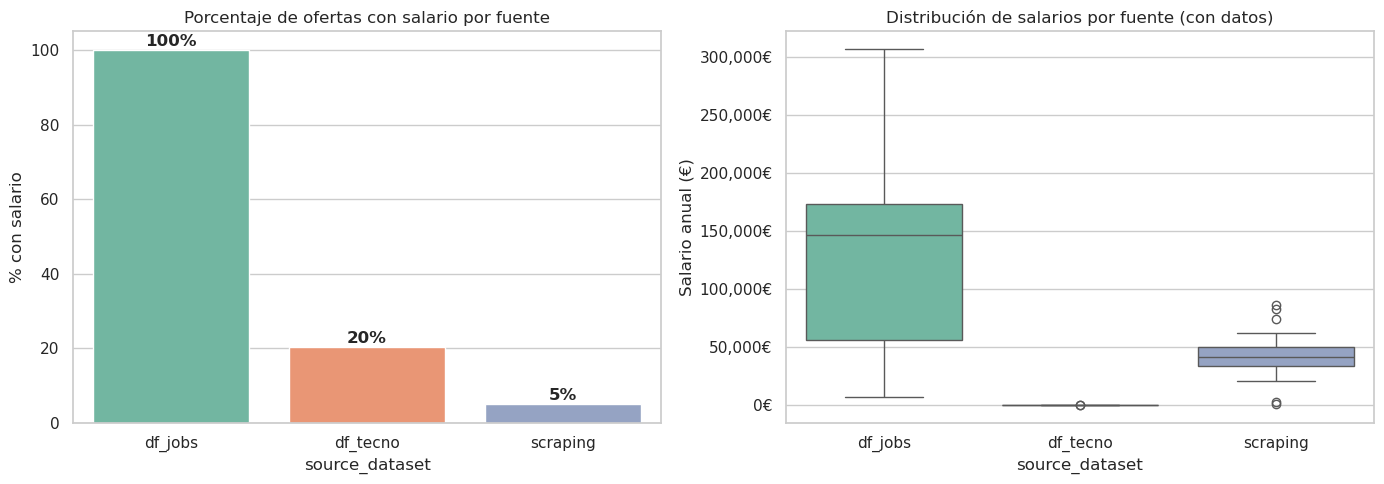

In [48]:
# 2. Sesgo de completitud salarial (versión final robusta)
total_es = len(jobs_es)
con_salario = jobs_es["salary_num"].notna().sum()
sin_salario = jobs_es["salary_num"].isna().sum()

print(f"Total ofertas en España: {total_es}")
print(f"Con salario numérico:  {con_salario} ({con_salario/total_es*100:.1f}%)")
print(f"Sin salario numérico:  {sin_salario} ({sin_salario/total_es*100:.1f}%)")

# Completitud salarial por fuente (usando size() para contar filas, no una columna)
salario_por_fuente = (
    jobs_es.groupby("source_dataset")
    .agg(
        total=("salary_num", "size"),              # size cuenta todas las filas del grupo
        con_salario=("salary_num", lambda x: x.notna().sum()),
    )
    .reset_index()
)
salario_por_fuente["pct_con_salario"] = (
    salario_por_fuente["con_salario"] / salario_por_fuente["total"] * 100
).round(2)

print("\nCompletitud salarial por fuente de datos:")
display(salario_por_fuente)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras: % con salario por fuente
sns.barplot(data=salario_por_fuente, x="source_dataset", y="pct_con_salario",
            hue="source_dataset", palette="Set2", legend=False, ax=axes[0])
axes[0].set_title("Porcentaje de ofertas con salario por fuente")
axes[0].set_ylabel("% con salario")
axes[0].set_ylim(0, 105)
for i, row in salario_por_fuente.iterrows():
    axes[0].text(i, row["pct_con_salario"] + 1, f"{row['pct_con_salario']:.0f}%",
                 ha="center", fontweight="bold")

# Boxplot: distribución salarial por fuente (solo ofertas con salario numérico)
sns.boxplot(data=jobs_es.dropna(subset=["salary_num"]),
            x="source_dataset", y="salary_num",
            hue="source_dataset", palette="Set2", legend=False, ax=axes[1])
axes[1].set_title("Distribución de salarios por fuente (con datos)")
axes[1].set_ylabel("Salario anual (€)")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}€"))

plt.tight_layout()
plt.show()

### Interpretación e impacto potencial

- Solo el 18.2 % de las ofertas españolas del dataset incluye dato salarial.  
  Esto implica que cualquier estadística retributiva (media, mediana, percentiles) se basa en menos de 1 de cada 5 ofertas.
- La fuente `df_jobs` (ofertas internacionales) publica salario en el 100 % de los casos, pero solo representa 92 ofertas.  
- `df_tecno` (TecnoEmpleo) tiene un 20.3 % de ofertas con salario.  
- `scraping` (Adzuna), que es la fuente más numerosa con 646 ofertas, solo aporta salario en un 5.1 % de los casos.  
  Esto confirma el sesgo de plataforma detectado en la fase de recolección: los portales de empleo españoles rara vez incluyen salario.
- Si DataTalent Solutions tomase decisiones salariales sin ponderar esta escasez de datos, podría:
  - Fijar bandas salariales poco competitivas (si las ofertas con salario son de empresas que pagan por encima o por debajo de la media).
  - Asumir erróneamente que la falta de salario implica salarios bajos, o viceversa.
- Mitigación: utilizar fuentes complementarias (encuestas salariales, informes de consultoría, datos del INE) para calibrar las cifras, e incluir siempre una advertencia sobre el porcentaje de datos ausentes.

## 3. Sesgo salarial por ciudad, sector y modalidad

¿Existen diferencias salariales significativas según la ubicación, la modalidad de trabajo o el sector de la empresa?  
Analizamos estas dimensiones para responder a la pregunta de negocio 2.

Ofertas españolas (df_tecno + scraping): 978
Con salario numérico (>=10k): 31

Salario mediano por ciudad (fuentes españolas, salarios >= 10k, mínimo 3 ofertas):


,n,mediana,media
city_clean,,,
Barcelona,13,44000.00,50438.46
Madrid,17,38000.00,41323.53


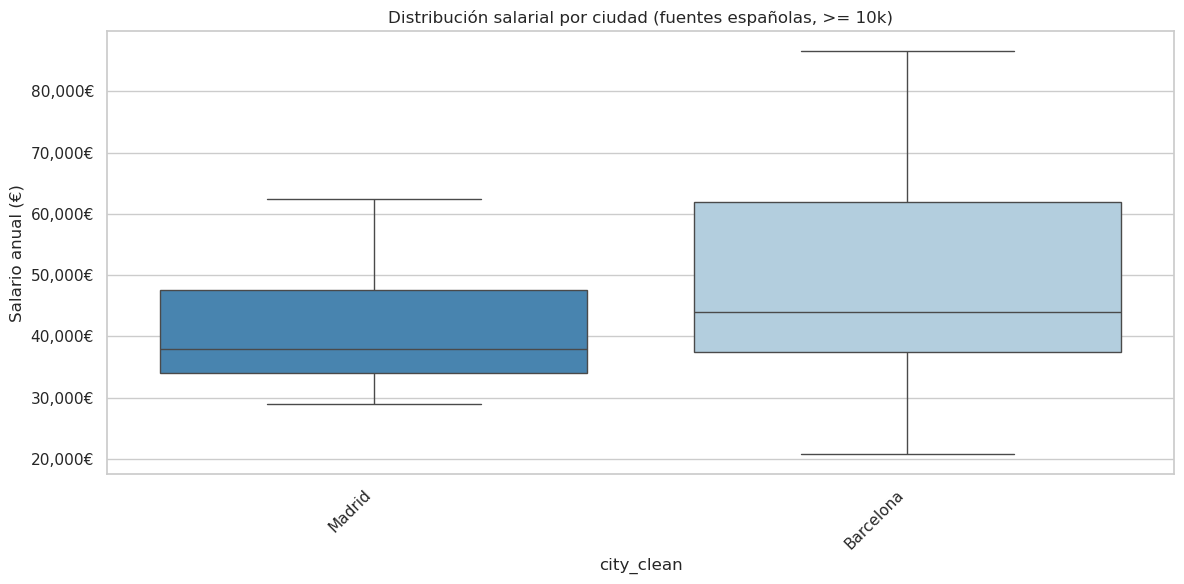


Salario mediano por modalidad de trabajo (fuentes españolas, >= 10k):


,work_modality,n,mediana,media
0,onsite,31,42500.00,45264.52


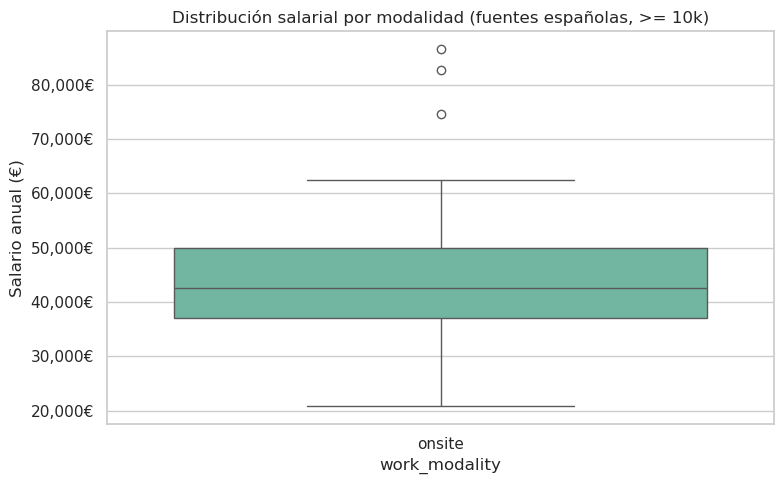


Salario mediano por sector (industry, >= 10k, mínimo 3 ofertas):


,n,mediana,media
industry,,,


In [51]:
# 3. Sesgo salarial: ciudad, modalidad, sector (FUENTES ESPAÑOLAS, FILTRADO)
# Excluimos df_jobs y salarios no verosímiles (< 10,000 €)

jobs_es_local = jobs_es[jobs_es["source_dataset"] != "df_jobs"].copy()

# Filtrar salarios verosímiles (>= 10,000 €)
jobs_es_local = jobs_es_local[
    jobs_es_local["salary_num"].isna() | (jobs_es_local["salary_num"] >= 10_000)
]

print(f"Ofertas españolas (df_tecno + scraping): {len(jobs_es_local)}")
print(f"Con salario numérico (>=10k): {jobs_es_local['salary_num'].notna().sum()}")

# --- 3.1 Salario por ciudad (mínimo 3 ofertas) ---
salario_ciudad = (
    jobs_es_local.dropna(subset=["salary_num"])
    .groupby("city_clean")
    .agg(
        n=("salary_num", "count"),
        mediana=("salary_num", "median"),
        media=("salary_num", "mean")
    )
    .query("n >= 3")
    .sort_values("mediana", ascending=False)
)

print("\nSalario mediano por ciudad (fuentes españolas, salarios >= 10k, mínimo 3 ofertas):")
display(salario_ciudad)

ciudades_con_datos = salario_ciudad.index.tolist()
df_ciudad_plot = jobs_es_local[
    jobs_es_local["city_clean"].isin(ciudades_con_datos) & jobs_es_local["salary_num"].notna()
]

if not df_ciudad_plot.empty:
    plt.figure(figsize=(12, 6))
    order = df_ciudad_plot.groupby("city_clean")["salary_num"].median().sort_values().index
    sns.boxplot(data=df_ciudad_plot, x="city_clean", y="salary_num",
                order=order, hue="city_clean", palette="Blues_r", legend=False)
    plt.title("Distribución salarial por ciudad (fuentes españolas, >= 10k)")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Salario anual (€)")
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}€"))
    plt.tight_layout()
    plt.show()
else:
    print("No hay suficientes datos salariales por ciudad para el gráfico.")

# --- 3.2 Salario por modalidad ---
if "work_modality" not in jobs_es_local.columns:
    jobs_es_local["work_modality"] = "unknown"
    mask_scrap = jobs_es_local["source_dataset"] == "scraping"
    jobs_es_local.loc[mask_scrap, "work_modality"] = jobs_es_local.loc[mask_scrap, "location"].apply(
        lambda x: "remote" if "remote" in str(x).lower() or "remoto" in str(x).lower() else "onsite"
    )

salario_modalidad = (
    jobs_es_local.dropna(subset=["salary_num"])
    .groupby("work_modality")
    .agg(
        n=("salary_num", "count"),
        mediana=("salary_num", "median"),
        media=("salary_num", "mean")
    )
    .reset_index()
)

print("\nSalario mediano por modalidad de trabajo (fuentes españolas, >= 10k):")
display(salario_modalidad)

if not salario_modalidad.empty:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=jobs_es_local.dropna(subset=["salary_num"]),
                x="work_modality", y="salary_num",
                order=salario_modalidad.sort_values("mediana")["work_modality"],
                hue="work_modality", palette="Set2", legend=False)
    plt.title("Distribución salarial por modalidad (fuentes españolas, >= 10k)")
    plt.ylabel("Salario anual (€)")
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}€"))
    plt.tight_layout()
    plt.show()

# --- 3.3 Salario por sector ---
if "industry" in jobs_es_local.columns:
    salario_sector = (
        jobs_es_local.dropna(subset=["salary_num", "industry"])
        .groupby("industry")
        .agg(
            n=("salary_num", "count"),
            mediana=("salary_num", "median"),
            media=("salary_num", "mean")
        )
        .query("n >= 3")
        .sort_values("mediana", ascending=False)
    )
    print("\nSalario mediano por sector (industry, >= 10k, mínimo 3 ofertas):")
    display(salario_sector.head(10))
else:
    print("\nLa columna 'industry' no está disponible en el dataset de fuentes españolas.")

### Interpretación e impacto potencial

- Solo 31 ofertas de fuentes españolas (3.2 %) contienen un salario anual verosímil.  
  La mayoría de los valores descartados eran inferiores a 10 000 €, probablemente salarios por hora o datos mal estructurados.
- Con tan pocos datos, las diferencias observadas entre Madrid (mediana 38 000 €) y Barcelona (44 000 €) deben interpretarse con cautela.
- No hay información salarial suficiente para analizar diferencias por modalidad de trabajo (remoto, híbrido, presencial) ni por sector industrial.
- Si DataTalent Solutions quiere diseñar bandas salariales competitivas por ciudad o sector, **necesitará obligatoriamente fuentes externas** (encuestas salariales, informes de consultoría) que complementen la escasez de datos de los portales de empleo.
- Este hallazgo refuerza la conclusión del sesgo de completitud salarial: el mercado laboral español publica muy pocos salarios, y eso limita cualquier análisis retributivo.

## 4. Sesgo demográfico (Stack Overflow)

Aunque la encuesta de Stack Overflow 2025 no incluye la variable de género, podemos analizar diferencias salariales según **edad, nivel educativo y situación laboral** para la muestra española, y contrastar si estos factores introducen sesgos relevantes.

Respuestas totales en Stack Overflow: 49,191
Respuestas desde España: 717
Respuestas con salario válido en España: 560

Salario por grupo de edad en España (Stack Overflow):


,GrupoEdad,respuestas,salario_mediano,salario_medio
0,<25,42,25523.00,31039.40
1,25-34,184,49886.00,64399.51
2,35-44,196,72509.00,83009.62
3,45-54,106,69609.00,77196.44
4,55-64,25,64968.00,65578.44
5,65+,7,40605.00,57172.29



Salario por nivel educativo en España (top 10, nombres originales en inglés):


,EdLevel,respuestas,salario_mediano,salario_medio
0,Some college/university study without earning ...,89,69609.00,79790.30
1,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",163,64968.00,74964.31
2,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",185,63808.00,72159.23
3,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",54,53193.00,64135.44
4,"Secondary school (e.g. American high school, G...",20,49363.00,55603.15
5,Primary/elementary school,6,47450.00,64736.17
6,"Associate degree (A.A., A.S., etc.)",36,40025.00,45892.28
7,Other (please specify):,6,34804.50,56073.83



Salario por situación laboral en España (top 10, nombres originales en inglés):


,Employment,respuestas,salario_mediano,salario_medio
0,Employed,460,60328.00,68355.26
1,"Independent contractor, freelancer, or self-em...",70,91522.50,101096.71
2,Not employed,13,46406.00,44933.38
3,Student,12,14502.00,16097.83
4,Retired,5,58007.00,69608.80


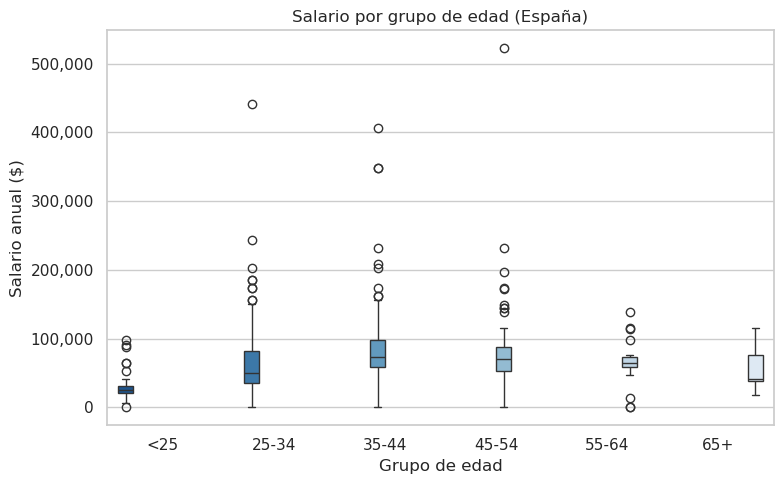

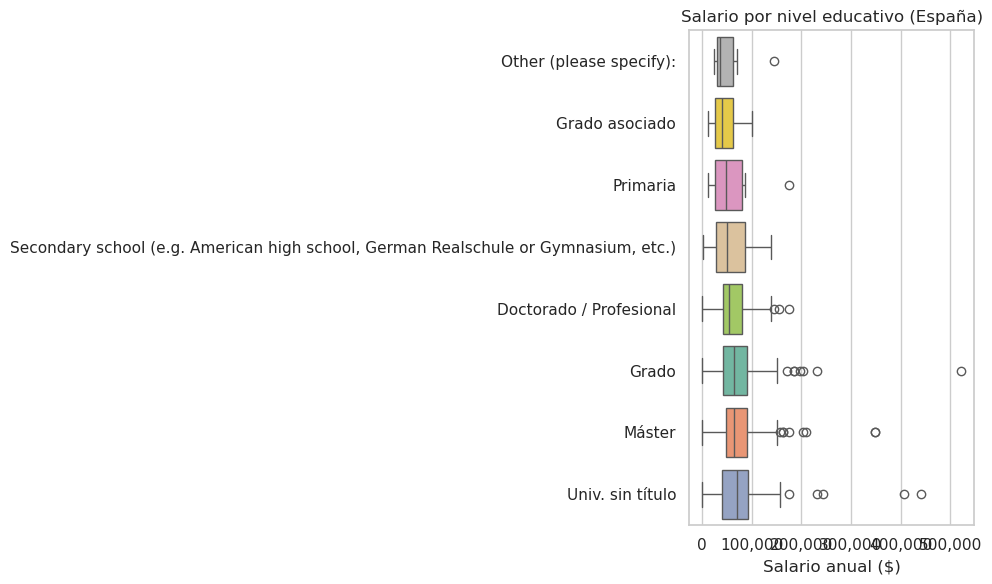

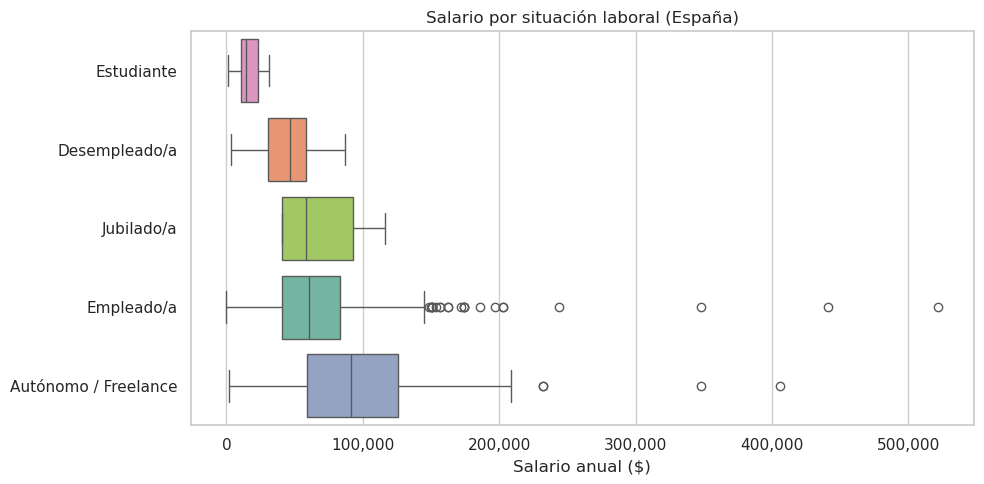

In [59]:
# ============================================================
# 4. SESGO DEMOGRÁFICO (STACK OVERFLOW)
# ============================================================

# Nota: las categorías de nivel educativo (EdLevel) y situación laboral (Employment)
# proceden de la encuesta internacional de Stack Overflow y se mantienen en inglés
# por fidelidad a la fuente original.

# 4.1 Filtrar encuesta a España y salarios válidos
mask_spain = stack_raw["Country"].str.strip().str.lower() == "spain"
stack_es = stack_raw[mask_spain].copy()
print(f"Respuestas totales en Stack Overflow: {len(stack_raw):,}")
print(f"Respuestas desde España: {len(stack_es):,}")

# Convertir salario a numérico
stack_es["ConvertedCompYearly"] = pd.to_numeric(stack_es["ConvertedCompYearly"], errors="coerce")
stack_es_sal = stack_es[stack_es["ConvertedCompYearly"].notna() & (stack_es["ConvertedCompYearly"] > 0)].copy()
print(f"Respuestas con salario válido en España: {len(stack_es_sal):,}")

# 4.2 Preparar edad numérica
age_map = {
    "18-24 years old": 21,
    "25-34 years old": 30,
    "35-44 years old": 40,
    "45-54 years old": 50,
    "55-64 years old": 60,
    "65 years or older": 70,
    "Prefer not to say": np.nan
}
stack_es_sal["EdadNumerica"] = stack_es_sal["Age"].map(age_map)

bins = [0, 24, 34, 44, 54, 64, 100]
labels = ["<25", "25-34", "35-44", "45-54", "55-64", "65+"]
stack_es_sal["GrupoEdad"] = pd.cut(stack_es_sal["EdadNumerica"], bins=bins, labels=labels, right=True)

salario_edad = (
    stack_es_sal.groupby("GrupoEdad", observed=False)
    .agg(
        respuestas=("ConvertedCompYearly", "count"),
        salario_mediano=("ConvertedCompYearly", "median"),
        salario_medio=("ConvertedCompYearly", "mean")
    )
    .reset_index()
    .dropna(subset=["GrupoEdad"])
)

print("\nSalario por grupo de edad en España (Stack Overflow):")
display(salario_edad)

# 4.3 Salario por nivel educativo
salario_educ = (
    stack_es_sal.groupby("EdLevel")
    .agg(
        respuestas=("ConvertedCompYearly", "count"),
        salario_mediano=("ConvertedCompYearly", "median"),
        salario_medio=("ConvertedCompYearly", "mean")
    )
    .sort_values("salario_mediano", ascending=False)
    .head(10)
    .reset_index()
)

print("\nSalario por nivel educativo en España (top 10, nombres originales en inglés):")
display(salario_educ)

# 4.4 Salario por situación laboral
salario_emp = (
    stack_es_sal.groupby("Employment")
    .agg(
        respuestas=("ConvertedCompYearly", "count"),
        salario_mediano=("ConvertedCompYearly", "median"),
        salario_medio=("ConvertedCompYearly", "mean")
    )
    .sort_values("respuestas", ascending=False)
    .head(10)
    .reset_index()
)

print("\nSalario por situación laboral en España (top 10, nombres originales en inglés):")
display(salario_emp)

# 4.5 Visualizaciones (3 gráficos independientes para mejor legibilidad)
# Todos los títulos y etiquetas en castellano.

# -- Gráfico 1: Edad --
fig1, ax1 = plt.subplots(figsize=(8, 5))
sns.boxplot(data=stack_es_sal.dropna(subset=["GrupoEdad"]), x="GrupoEdad", y="ConvertedCompYearly",
            hue="GrupoEdad", palette="Blues_r", legend=False, ax=ax1)
ax1.set_title("Salario por grupo de edad (España)")
ax1.set_xlabel("Grupo de edad")
ax1.set_ylabel("Salario anual ($)")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
fig1.tight_layout()
plt.show()

# -- Gráfico 2: Educación (nombres acortados para legibilidad) --
top_ed = stack_es_sal["EdLevel"].value_counts().head(8).index
df_ed = stack_es_sal[stack_es_sal["EdLevel"].isin(top_ed)].copy()
short_names = {
    "Some college/university study without earning a degree": "Univ. sin título",
    "Master’s degree (M.A., M.S., M.Eng., MBA, etc.)": "Máster",
    "Bachelor’s degree (B.A., B.S., B.Eng., etc.)": "Grado",
    "Professional degree (JD, MD, Ph.D, Ed.D, etc.)": "Doctorado / Profesional",
    "Secondary school (e.g. American high school, German ...": "Secundaria",
    "Primary/elementary school": "Primaria",
    "Associate degree (A.A., A.S., etc.)": "Grado asociado",
}
df_ed["EdLevelCorto"] = df_ed["EdLevel"].map(short_names).fillna(df_ed["EdLevel"])
order_ed = df_ed.groupby("EdLevelCorto")["ConvertedCompYearly"].median().sort_values().index

fig2, ax2 = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_ed, y="EdLevelCorto", x="ConvertedCompYearly",
            order=order_ed, hue="EdLevelCorto", palette="Set2", legend=False, ax=ax2)
ax2.set_title("Salario por nivel educativo (España)")
ax2.set_xlabel("Salario anual ($)")
ax2.set_ylabel("")
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
fig2.tight_layout()
plt.show()

# -- Gráfico 3: Empleo (nombres acortados) --
top_emp = stack_es_sal["Employment"].value_counts().head(6).index
df_emp = stack_es_sal[stack_es_sal["Employment"].isin(top_emp)].copy()
short_emp = {
    "Employed": "Empleado/a",
    "Independent contractor, freelancer, or self-employed": "Autónomo / Freelance",
    "Not employed": "Desempleado/a",
    "Student": "Estudiante",
    "Retired": "Jubilado/a",
}
df_emp["EmpleoCorto"] = df_emp["Employment"].map(short_emp).fillna(df_emp["Employment"])
order_emp = df_emp.groupby("EmpleoCorto")["ConvertedCompYearly"].median().sort_values().index

fig3, ax3 = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_emp, y="EmpleoCorto", x="ConvertedCompYearly",
            order=order_emp, hue="EmpleoCorto", palette="Set2", legend=False, ax=ax3)
ax3.set_title("Salario por situación laboral (España)")
ax3.set_xlabel("Salario anual ($)")
ax3.set_ylabel("")
ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
fig3.tight_layout()
plt.show()

### Interpretación e impacto potencial

- La muestra española de Stack Overflow (560 respuestas con salario) revela un **crecimiento salarial progresivo con la edad**, que se estabiliza en la franja de 35-54 años (mediana ~70 000 $) y desciende ligeramente a partir de los 55.
- Las personas **menores de 25 años** presentan la mediana más baja (25 523 $), lo que sugiere que los perfiles junior están representados en la encuesta.
- Por nivel educativo, **los estudios universitarios (sin título, máster, grado) dominan la muestra y se asocian a salarios más altos**. Sin embargo, hay pocas respuestas de personas con estudios básicos (primaria: 6 respuestas; secundaria: 20), lo que supone un **sesgo de representatividad** hacia perfiles altamente cualificados.
- Por situación laboral, la mayoría son personas **empleadas** (460 respuestas). Los **autónomos/freelance** reportan los salarios más altos (mediana 91 522 $), aunque son solo 70 respuestas. Los estudiantes tienen la mediana más baja (14 502 $), como era esperable.
- Dado que no disponemos de la variable de género en la edición 2025 de la encuesta, **no podemos evaluar diferencias salariales por género**. Esta es una limitación relevante que DataTalent Solutions deberá suplir con otras fuentes (INE, Eurostat, informes sectoriales).

## 5. Conclusiones y recomendaciones para DataTalent Solutions

El análisis de sesgos de los datos disponibles revela limitaciones importantes que deben tenerse en cuenta antes de tomar decisiones estratégicas sobre la nueva línea de reskilling.

### Principales hallazgos

1. **Sesgo geográfico**  
   - Madrid (43 %) y Barcelona (30 %) concentran casi tres cuartas partes de las ofertas españolas analizadas.  
   - Solo aparecen 18 ubicaciones distintas, lo que deja fuera a la mayoría de provincias y comunidades autónomas.  
   - El 6.8 % de ofertas remotas mitiga parcialmente este sesgo.

2. **Sesgo de completitud salarial**  
   - Únicamente el 18 % de las ofertas en España publica el salario.  
   - De las fuentes españolas (`df_tecno` y `scraping`), solo 31 ofertas (3.2 %) contienen un salario anual verosímil (≥ 10 000 €).  
   - Esto impide un análisis retributivo sólido por ciudad, sector o modalidad.

3. **Sesgo demográfico (Stack Overflow)**  
   - La muestra española de la encuesta (560 respuestas con salario) está sobrerrepresentada por perfiles con estudios superiores y empleados a tiempo completo.  
   - No se dispone de la variable de género en la edición 2025, lo que impide evaluar diferencias salariales por esta dimensión.

### Limitaciones que afectan a las decisiones

- Los análisis salariales solo son representativos de la minoría de ofertas que publican salario, habitualmente de grandes empresas y sectores con políticas de transparencia.  
- Las conclusiones geográficas reflejan dónde se publican más ofertas en los portales analizados, no necesariamente dónde hay más demanda real de talento.  
- La encuesta de Stack Overflow refleja la realidad de profesionales con presencia en comunidades técnicas internacionales, no necesariamente el mercado laboral español en su conjunto.

### Recomendaciones para DataTalent Solutions

1. **Complementar con fuentes externas** antes de fijar bandas salariales o decidir ubicaciones de los programas formativos:  
   - Encuestas salariales sectoriales (INE, Eurostat, consultoras especializadas).  
   - Datos de empleo regional (SEPE, observatorios autonómicos).  
   - Informes de asociaciones tecnológicas españolas.

2. **Tomar con cautela los datos salariales actuales** y presentarlos siempre acompañados del porcentaje de ofertas que publican salario y del número real de observaciones que respaldan cada cifra.

3. **Priorizar el diseño de programas de reskilling en modalidad remota o híbrida**, ya que esto permite llegar a talento de cualquier región y mitigar el sesgo geográfico detectado.

4. **Solicitar o buscar datos desagregados por género** para poder evaluar esta dimensión de equidad, que ha quedado fuera del presente análisis por indisponibilidad en las fuentes utilizadas.

---

*Este análisis de sesgos debe ser actualizado cuando se disponga de más datos del mercado español, especialmente en lo relativo a salarios y cobertura geográfica.*